---

## Libraries & Setup

We use the following libraries for:
- Data manipulation: Pandas, NumPy
- Visualization: Matplotlib, Seaborn
- Modeling: DBSCAN, XGBoost, CatBoost
- Optimization: Optuna

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import optuna
import joblib
from catboost import CatBoostRegressor
import xgboost as xgb
import os
RANDOM_STATE = 42

OPTUNA_PATH = "optuna_best_params.pkl"
XMODEL_PATH = "Xgb_price_model.pkl"
XPRED_PATH = "xgb_preds.pkl"

FORCE_RETRAIN = False
FORCE_OPTUNA = False

CMODEL_PATH = "Catboost_model.pkl"
CPRED_PATH = "Catboost_preds.pkl"
CBEST_PARAM_PATH = "catboost_best_params.pkl"
FORCE_TUNE = False


---

# Data Cleaning & Feature Extraction

---

## Data Collection

The dataset consists of scraped real estate listings with the following features:
- City
- Property title
- Price
- Price per sqft
- Property details and descriptions

In [2]:
df = pd.read_csv(r"C:\Users\anand\magicbricks_data_final_5.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   city           6000 non-null   object
 1   title          6000 non-null   object
 2   price          6000 non-null   object
 3   sqft_price     5536 non-null   object
 4   property_name  3928 non-null   object
 5   summary        5999 non-null   object
 6   posted_by      4967 non-null   object
 7   description    4622 non-null   object
dtypes: object(8)
memory usage: 375.1+ KB


###  Initial Observations
- Dataset contains ~6000 entries
- Several columns have missing values
- Price and sqft_price are stored as text and require cleaning

##  Data Cleaning

### Cleaning Price Column

The `price` column contains:
- Currency symbols (₹)
- Commas
- Text formatting

We convert it into a numeric format for modeling.

In [3]:
def clean_price(price):
    if pd.isna(price):
        return np.nan
    
    # Convert to string
    price = str(price)
    
    # Remove currency symbols and formatting
    price = price.replace("₹", "").replace(",", "").replace("\n", "").strip()
    
    # Handle invalid entries
    if price.lower() == "price" or price == "":
        return np.nan
    
    try:
        # Extract number
        value = float(re.findall(r"[\d.]+", price)[0])

        # Convert values into numeric format (float)
        # Convert based on unit
        if "Cr" in price or "Crore" in price:
            return value * 1e7   # 1 Crore = 10,000,000
        
        elif "Lac" in price or "Lakh" in price:
            return value * 1e5   # 1 Lakh = 100,000
        
        else:
            return value  # already in rupees (rare case)
    
    except:
        return np.nan


In [4]:
# Apply to dataframe
df["price"] = df["price"].apply(clean_price)

In [5]:
# inspecting the title column
with pd.option_context('display.max_colwidth', None):
    print(df.title.sample(20))

1399                          3 BHK  House for Sale in ever green  vengambakam Chennai
3819                                   4 BHK Villa for Sale in Nizampet Road Hyderabad
4743                  3 BHK Apartment for Sale in Kanakia Silicon Valley, Powai Mumbai
3584                                 4 BHK Apartment for Sale in Hitech City Hyderabad
4528                   2 BHK Flat  for Sale in  ACE Rushi Vihar NX, Virar East, Mumbai
5305                                   1 BHK Apartment for Sale in Dahisar West Mumbai
217                                       2 BHK Apartment for Sale in Ambattur Chennai
4684                  3 BHK Apartment for Sale in Concrete Sai Swaroop, Chembur Mumbai
4361                               2 BHK Flat  for Sale in  Manikonda Jagir, Hyderabad
3202                                  2 BHK Apartment for Sale in Bachupally Hyderabad
578                                     2 BHK Apartment for Sale in Saligramam Chennai
4356                                    2 B

##  Feature Engineering

We extract structured information from unstructured text fields such as:
- Number of bedrooms (BHK)
- Area (sqft)
- Property type

This improves model performance by converting raw text into usable features.

In [6]:

cities = ["Chennai", "Bangalore", "Hyderabad", "Mumbai"]

# ---------- FUNCTION ----------
def extract_features(title):
    if pd.isna(title):
        return pd.Series([None, None, None])
    
    title = str(title)

    # -------- BHK --------
    bhk_match = re.search(r'(\d+)\s*BHK', title, re.IGNORECASE)
    bhk = int(bhk_match.group(1)) if bhk_match else None

    # -------- PROPERTY TYPE --------
    property_types = [
        "Apartment", "Villa", "House", "Flat", "Builder Floor", "Penthouse", "Studio"
    ]
    
    property_type = None
    for ptype in property_types:
        if re.search(ptype, title, re.IGNORECASE):
            property_type = ptype
            break

    # -------- LOCATION --------
    location = None
    loc_match = re.search(r'for Sale in (.+)', title, re.IGNORECASE)
    
    if loc_match:
        location = loc_match.group(1).strip()
        
        # Remove city names
        for city in cities:
            location = re.sub(rf'\b{city}\b', '', location, flags=re.IGNORECASE)
        
        # Remove extra commas/spaces
        location = location.replace(",", "").strip()

    return pd.Series([bhk, property_type, location])

In [7]:
#  Applying the function
df[["bhk", "property_type", "location"]] = df["title"].apply(extract_features)

In [8]:
df.isna().sum()

city                0
title               0
price               0
sqft_price        464
property_name    2072
summary             1
posted_by        1033
description      1378
bhk                14
property_type       0
location            0
dtype: int64

Features Extracted Title: bhk, property_type and location (3)

### Extracting freatures from summary column

In [9]:
df['summary'].unique()

array(["Super Area | 993 sqft | Under Construction | Poss. by Aug '28 | Transaction | New Property | Furnishing | Unfurnished | Car Parking | 1 Covered | Bathroom | 2",
       "Super Area | 1619 sqft | Under Construction | Poss. by Dec '26 | Transaction | New Property | Furnishing | Unfurnished | Car Parking | 1 Covered | Bathroom | 3",
       'Super Area | 2578 sqft | Transaction | New Property | Furnishing | Unfurnished | Bathroom | 4 | Balcony | 2',
       ...,
       'Carpet Area | 362 sqft | Status | Ready to Move | Floor | 2 out of 38 | Transaction | Resale | Furnishing | Unfurnished | Society | Wadhwa Pristine | Bathroom | 1',
       'Carpet Area | 378 sqft | Status | Ready to Move | Floor | 4 out of 4 | Transaction | Resale | Furnishing | Unfurnished | Society | Dwarka Shopping Centre | Bathroom | 1',
       'Carpet Area | 864 sqft | Status | Ready to Move | Floor | 4 out of 5 | Transaction | Resale | Furnishing | Semi-Furnished | Society | Rashmi Mangal Nagar | Bathroom | 2'],

In [10]:
# Inpecting the unique category types present in summary column to figure out which features to extract
unique_categories = (
    df['summary'].dropna()
    .str.split('|')               # Split into lists
    .apply(lambda x: x[0::2])     # Slice: index to only extracts the cateogry types and not the values
    .explode()                    # Turn lists into individual rows
    .unique()                     # Get only unique values
)

In [11]:
unique_categories

array(['Super Area ', ' Under Construction ', ' Transaction ',
       ' Furnishing ', ' Car Parking ', ' Bathroom ', ' Balcony ',
       'Carpet Area ', ' Status ', ' Floor ', ' facing ', ' overlooking ',
       ' Ownership ', ' Dimensions ', 'Transaction ', 'Status ',
       ' Society '], dtype=object)

In [12]:
# Function to extract structured features from the 'summary' column
def extract_summary_features(df):

    # Inner function to process a single summary string
    def parse_summary(summary):
        result = {}  # Dictionary to store extracted key-value pairs

        # Handle missing values (NaN)
        if pd.isna(summary):
            return result

        # Split the summary string using the delimiter " | "
        # This creates a list like: [key1, value1, key2, value2, ...]
        parts = summary.split(" | ")

        # Iterate through the list in steps of 2:
        # index 0 → key, index 1 → value
        # index 2 → next key, index 3 → next value, and so on
        for i in range(0, len(parts) - 1, 2):
            
            # Clean and standardize the key:
            # - remove leading/trailing spaces
            # - convert to lowercase
            # - replace spaces with underscores (snake_case)
            key = parts[i].strip().lower().replace(" ", "_")
            
            # Extract the corresponding value and clean whitespace
            value = parts[i + 1].strip()

            # Store the key-value pair in dictionary
            result[key] = value

        # Return dictionary for that row
        return result

    # Apply parsing function to the entire 'summary' column
    # Each row becomes a dictionary of extracted features
    # .apply(pd.Series) expands dictionary keys into separate columns
    summary_df = df['summary'].apply(parse_summary).apply(pd.Series)

    # Concatenate the new columns with the original dataframe
    # axis=1 ensures columns are added horizontally
    return pd.concat([df, summary_df], axis=1)

In [13]:
# Applying function
df = extract_summary_features(df)

Features extracted from summary column: Super Area, Under Construction, Transaction, Furnishing,   
Car Parking, Bathroom, Balcony, Carpet Area, Status, Floor, facing,  
overlooking, Ownership,  Dimensions, Transaction, Status , Society  (17)

 ### Cleaning and logically imputing super area sqft column

In [14]:
# 3979 missing values
df['super_area'].isna().sum()

np.int64(3979)

In [15]:
# checking to see if there are rows with values in both super and carpet area together
df[df['super_area'].notna() & df['carpet_area'].notna()]

,city,title,price,sqft_price,property_name,summary,posted_by,description,bhk,property_type,...,bathroom,balcony,carpet_area,status,floor,facing,overlooking,ownership,dimensions,society


In [16]:
# function to clean, extract and calculate super area 
def create_super_area_sqft(df):

    #  STEP 1: Extract numeric values 
    df['super_area_num'] = df['super_area'].str.extract(r'(\d+)').astype(float)
    df['carpet_area_num'] = df['carpet_area'].str.extract(r'(\d+)').astype(float)

    # STEP 2: Convert carpet → equivalent super area 
    df['carpet_to_super'] = df['carpet_area_num'] / 0.75

    #  STEP 3: Merge columns 
    # Use super_area if available, else fallback to converted carpet_area
    df['super_area_sqft'] = df['super_area_num'].combine_first(df['carpet_to_super'])

    #  STEP 4: cleanup 
    df.drop(columns=['super_area_num', 'carpet_area_num', 'carpet_to_super', 'super_area', 'carpet_area'], inplace=True)

    return df

In [17]:
# Applying the function
create_super_area_sqft(df)

,city,title,price,sqft_price,property_name,summary,posted_by,description,bhk,property_type,...,bathroom,balcony,status,floor,facing,overlooking,ownership,dimensions,society,super_area_sqft
0,Chennai,"2 BHK Flat for Sale in Kelambakkam, Chennai",6460000.0,"₹6,509 per sqft",Provident Bayscape,Super Area | 993 sqft | Under Construction | P...,Builder: Provident Housing Ltd.,This modern 2 BHK property is situated in Kela...,2.0,Flat,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,993.000000
1,Chennai,"3 BHK Flat for Sale in Tondiarpet, Chennai",14600000.0,"₹9,041 per sqft",KG North Bay,Super Area | 1619 sqft | Under Construction | ...,Builder: KG Builders,"This 3 BHK apartment in Tondiarpet, Chennai is...",3.0,Flat,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1619.000000
2,Chennai,"4 BHK Flat for Sale in Kundrathur, Chennai",13700000.0,"₹5,314 per sqft",Casagrand Massimo,Super Area | 2578 sqft | Transaction | New Pro...,NaN,"Multistorey Apartment for Sale in Kundrathur, ...",4.0,Flat,...,4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2578.000000
3,Chennai,"2 BHK Flat for Sale in Pallavaram, Chennai",13200000.0,NaN,Prestige Pallava Gardens,Carpet Area | 740 sqft | Under Construction | ...,NaN,"2 Bedroom, Multistorey Apartment for Sale in P...",2.0,Flat,...,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,986.666667
4,Chennai,"3 BHK Flat for Sale in Sholinganallur, Chennai",20700000.0,"₹11,993 per sqft",Brigade Altius,Super Area | 1726 sqft | Under Construction | ...,NaN,Multistorey Apartment for Sale in Sholinganall...,3.0,Flat,...,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1726.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,Mumbai,2 BHK Flat for Sale in Veena Vihar Cooperati...,17500000.0,"₹23,333 per sqft",Veena Vihar Cooperative Housing Society,Carpet Area | 540 sqft | Status | Ready to Mov...,Owner: Vishal Pandey,NaN,2.0,Flat,...,2,NaN,Ready to Move,3 out of 6,NaN,NaN,NaN,NaN,Veena Vihar Cooperative Housing Society,720.000000
5996,Mumbai,"2 BHK Flat for Sale in Kalpataru Yashodhan, ...",38500000.0,"₹51,265 per sqft",Kalpataru Yashodhan,Carpet Area | 541 sqft | Status | Ready to Mov...,Owner: soumya ranjan sahu,NaN,2.0,Flat,...,2,NaN,Ready to Move,2 out of 13,NaN,NaN,NaN,NaN,Kalpataru Yashodhan,721.333333
5997,Mumbai,"1 BHK Flat for Sale in Wadhwa Pristine, Matu...",27000000.0,"₹53,678 per sqft",Wadhwa Pristine,Carpet Area | 362 sqft | Status | Ready to Mov...,Owner: Tanay gulati,NaN,1.0,Flat,...,1,NaN,Ready to Move,2 out of 38,NaN,NaN,NaN,NaN,Wadhwa Pristine,482.666667
5998,Mumbai,1 BHK Flat for Sale in Dwarka Shopping Centr...,8000000.0,"₹15,238 per sqft",Dwarka Shopping Centre,Carpet Area | 378 sqft | Status | Ready to Mov...,Owner: Soumita kanjilal,NaN,1.0,Flat,...,1,NaN,Ready to Move,4 out of 4,NaN,NaN,NaN,NaN,Dwarka Shopping Centre,504.000000


In [18]:
#Completely filled
df['super_area_sqft'].isna().sum()

np.int64(6)

### Handling missing values in property name

In [19]:
# filling null values of property_name incase the appear in society 
df['property_name'] = df['property_name'].fillna(df['society'])

In [20]:
df['posted_by'].unique()

array(['Builder: Provident Housing Ltd.', 'Builder: KG Builders', nan,
       ..., 'Owner: Tanay gulati', 'Owner: Soumita kanjilal',
       'Owner: Soumen Kumar Dey'], shape=(4425,), dtype=object)

In [21]:
df['posted_by'].dropna().str.split(':').str[0].unique()

array(['Builder', 'Agent', 'Owner'], dtype=object)

In [22]:
# ---------- STEP 1: Extract name after ":" ----------
df['posted_name'] = df['posted_by'].str.extract(r':\s*(.*)')


# ---------- STEP 2: Fill missing property_name ----------
df['property_name'] = df['property_name'].fillna(df['posted_name'])

# ---------- STEP 3: Cleanup ----------
df.drop(columns=['posted_name'], inplace=True)

### Handling missing values in status

under_construction column has dates of possible completion, and status has ready to move or null values( assuming null = under construction)

In [23]:
# if under construction is not null and status is null then proerty should be should be under construction 
df[df['under_construction'].notna() & df['status'].isna()]

,city,title,price,sqft_price,property_name,summary,posted_by,description,bhk,property_type,...,bathroom,balcony,status,floor,facing,overlooking,ownership,dimensions,society,super_area_sqft
0,Chennai,"2 BHK Flat for Sale in Kelambakkam, Chennai",6460000.0,"₹6,509 per sqft",Provident Bayscape,Super Area | 993 sqft | Under Construction | P...,Builder: Provident Housing Ltd.,This modern 2 BHK property is situated in Kela...,2.0,Flat,...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,993.000000
1,Chennai,"3 BHK Flat for Sale in Tondiarpet, Chennai",14600000.0,"₹9,041 per sqft",KG North Bay,Super Area | 1619 sqft | Under Construction | ...,Builder: KG Builders,"This 3 BHK apartment in Tondiarpet, Chennai is...",3.0,Flat,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1619.000000
3,Chennai,"2 BHK Flat for Sale in Pallavaram, Chennai",13200000.0,NaN,Prestige Pallava Gardens,Carpet Area | 740 sqft | Under Construction | ...,NaN,"2 Bedroom, Multistorey Apartment for Sale in P...",2.0,Flat,...,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,986.666667
4,Chennai,"3 BHK Flat for Sale in Sholinganallur, Chennai",20700000.0,"₹11,993 per sqft",Brigade Altius,Super Area | 1726 sqft | Under Construction | ...,NaN,Multistorey Apartment for Sale in Sholinganall...,3.0,Flat,...,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1726.000000
5,Chennai,"3 BHK Flat for Sale in OMR, Chennai",9150000.0,"₹7,124 per sqft",BSCPL Bollineni ZION,Super Area | 1285 sqft | Under Construction | ...,NaN,"Multistorey Apartment for Sale in OMR, Chennai...",3.0,Flat,...,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1285.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5610,Mumbai,4 BHK Flat for Sale in Hiranandani Empress H...,110000000.0,"₹57,895 per sqft",Hiranandani Empress Hill,Carpet Area | 1600 sqft | Under Construction |...,Agent: Akanksha Sahay,Most Premium development of Hiranandani Garden...,4.0,Flat,...,5,5,NaN,19 out of 22,East,"Pool, Garden/Park, Main Road",Freehold,NaN,Hiranandani Empress Hill,2133.333333
5611,Mumbai,3 BHK Flat for Sale in Paradise Sai World Le...,12500000.0,"₹7,425 per sqft",Paradise Sai World Legend,Carpet Area | 1079 sqft | Under Construction |...,Agent: Ojas Realty,Sai World Legend A Lifestyle of Legends With L...,3.0,Flat,...,3,5,NaN,9 out of 30,East,"Garden/Park, Pool, Main Road",Freehold,NaN,Paradise Sai World Legend,1438.666667
5645,Mumbai,1 BHK Flat for Sale in Impactum The Great We...,3800000.0,"₹16,814 per sqft",Impactum The Great Western Mumbai,Carpet Area | 323 sqft | Under Construction | ...,Agent: Dright Properties,"Situated at a prime location of Naigaon East, ...",1.0,Flat,...,1,1,NaN,7 out of 35,North,Garden/Park,Freehold,NaN,Impactum The Great Western Mumbai,430.666667
5778,Mumbai,3 BHK Flat for Sale in Chandak Highscape Cit...,25600000.0,NaN,Chandak Highscape City,Carpet Area | 848 sqft | Under Construction | ...,Agent: Magicbricks,Discover a better world at Chandak Highscape C...,3.0,Flat,...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chandak Highscape City,1130.666667


In [24]:
df['status'].unique()

array([nan, 'Ready to Move'], dtype=object)

In [25]:
df.loc[df['status'].isna() & df['under_construction'].notna(),'status'] = 'under construction'

Creating a binary column ready to move, 1 means yes and 0 means no

In [26]:
df['ready_to_move'] = pd.NA

df.loc[df['status'].str.lower() == 'ready to move', 'ready_to_move'] = 1
df.loc[df['status'] == 'under construction', 'ready_to_move'] = 0

df['ready_to_move'] = df['ready_to_move'].astype('Int64')

In [27]:
df['ready_to_move'].unique()

<IntegerArray>
[0, <NA>, 1]
Length: 3, dtype: Int64

### Creating Parking related features

In [28]:
# unique values in car_parking column
df['car_parking'].unique()

array(['1 Covered', nan, '1 Open', '1 Covered,', '2 Covered', '4 Covered',
       '6 Covered', '150 Open', '3 Covered', '2 Covered,', '3 Covered,',
       '5 Covered', '4 Covered,', '2 Open', '5 Covered,', '77 Covered',
       '56 Covered,', '8 Open', '69 Open', '190 Covered', '243 Open',
       '201 Covered', '612 Covered', '403 Open', '10 Covered',
       '101 Covered', '123 Covered', '565 Covered', '7 Covered',
       '8 Covered', '4 Open', '205 Covered', '103 Open', '999 Covered',
       '8 Covered,', '305 Covered', '11 Covered', '20 Covered',
       '103 Covered', '302 Covered', '401 Covered', '306 Covered',
       '30 Covered', '10 Open', '144 Covered', '7 Open', '100 Open',
       '3 Open'], dtype=object)

Splitting car_parking column into covered and open parking and extracting out only the numerical values for them using regular expression(re)

In [29]:

def split_parking(df):

    def extract_parking(text):
        covered = 0
        open_ = 0

        if pd.isna(text):
            return pd.Series([None, None])

        text = str(text).lower()

        # Covered parking
        covered_match = re.search(r'(\d+)\s*covered', text)
        if covered_match:
            covered = int(covered_match.group(1))

        # Open parking
        open_match = re.search(r'(\d+)\s*open', text)
        if open_match:
            open_ = int(open_match.group(1))

        # If only number exists (no type mentioned)
        if covered == 0 and open_ == 0:
            num_match = re.search(r'(\d+)', text)
            if num_match:
                covered = int(num_match.group(1))  # assume covered by default

        return pd.Series([covered, open_])

    df[['covered_parking', 'open_parking']] = df['car_parking'].apply(extract_parking)

    return df

In [30]:
# Applying the funciton
split_parking(df)

,city,title,price,sqft_price,property_name,summary,posted_by,description,bhk,property_type,...,floor,facing,overlooking,ownership,dimensions,society,super_area_sqft,ready_to_move,covered_parking,open_parking
0,Chennai,"2 BHK Flat for Sale in Kelambakkam, Chennai",6460000.0,"₹6,509 per sqft",Provident Bayscape,Super Area | 993 sqft | Under Construction | P...,Builder: Provident Housing Ltd.,This modern 2 BHK property is situated in Kela...,2.0,Flat,...,NaN,NaN,NaN,NaN,NaN,NaN,993.000000,0,1.0,0.0
1,Chennai,"3 BHK Flat for Sale in Tondiarpet, Chennai",14600000.0,"₹9,041 per sqft",KG North Bay,Super Area | 1619 sqft | Under Construction | ...,Builder: KG Builders,"This 3 BHK apartment in Tondiarpet, Chennai is...",3.0,Flat,...,NaN,NaN,NaN,NaN,NaN,NaN,1619.000000,0,1.0,0.0
2,Chennai,"4 BHK Flat for Sale in Kundrathur, Chennai",13700000.0,"₹5,314 per sqft",Casagrand Massimo,Super Area | 2578 sqft | Transaction | New Pro...,NaN,"Multistorey Apartment for Sale in Kundrathur, ...",4.0,Flat,...,NaN,NaN,NaN,NaN,NaN,NaN,2578.000000,<NA>,NaN,NaN
3,Chennai,"2 BHK Flat for Sale in Pallavaram, Chennai",13200000.0,NaN,Prestige Pallava Gardens,Carpet Area | 740 sqft | Under Construction | ...,NaN,"2 Bedroom, Multistorey Apartment for Sale in P...",2.0,Flat,...,NaN,NaN,NaN,NaN,NaN,NaN,986.666667,0,NaN,NaN
4,Chennai,"3 BHK Flat for Sale in Sholinganallur, Chennai",20700000.0,"₹11,993 per sqft",Brigade Altius,Super Area | 1726 sqft | Under Construction | ...,NaN,Multistorey Apartment for Sale in Sholinganall...,3.0,Flat,...,NaN,NaN,NaN,NaN,NaN,NaN,1726.000000,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,Mumbai,2 BHK Flat for Sale in Veena Vihar Cooperati...,17500000.0,"₹23,333 per sqft",Veena Vihar Cooperative Housing Society,Carpet Area | 540 sqft | Status | Ready to Mov...,Owner: Vishal Pandey,NaN,2.0,Flat,...,3 out of 6,NaN,NaN,NaN,NaN,Veena Vihar Cooperative Housing Society,720.000000,1,NaN,NaN
5996,Mumbai,"2 BHK Flat for Sale in Kalpataru Yashodhan, ...",38500000.0,"₹51,265 per sqft",Kalpataru Yashodhan,Carpet Area | 541 sqft | Status | Ready to Mov...,Owner: soumya ranjan sahu,NaN,2.0,Flat,...,2 out of 13,NaN,NaN,NaN,NaN,Kalpataru Yashodhan,721.333333,1,NaN,NaN
5997,Mumbai,"1 BHK Flat for Sale in Wadhwa Pristine, Matu...",27000000.0,"₹53,678 per sqft",Wadhwa Pristine,Carpet Area | 362 sqft | Status | Ready to Mov...,Owner: Tanay gulati,NaN,1.0,Flat,...,2 out of 38,NaN,NaN,NaN,NaN,Wadhwa Pristine,482.666667,1,NaN,NaN
5998,Mumbai,1 BHK Flat for Sale in Dwarka Shopping Centr...,8000000.0,"₹15,238 per sqft",Dwarka Shopping Centre,Carpet Area | 378 sqft | Status | Ready to Mov...,Owner: Soumita kanjilal,NaN,1.0,Flat,...,4 out of 4,NaN,NaN,NaN,NaN,Dwarka Shopping Centre,504.000000,1,NaN,NaN


In [31]:
# inspecting the result
df.loc[df['car_parking'].notna(), ['car_parking','covered_parking', 'open_parking']]

,car_parking,covered_parking,open_parking
0,1 Covered,1.0,0.0
1,1 Covered,1.0,0.0
15,1 Open,0.0,1.0
20,1 Covered,1.0,0.0
21,1 Covered,1.0,0.0
...,...,...,...
5809,1 Open,0.0,1.0
5810,1 Covered,1.0,0.0
5822,3 Open,0.0,3.0
5888,1 Open,0.0,1.0


In [32]:
# inspecting descritpion column to see if it has parking information
df['description'].unique()

array(["This modern 2 BHK property is situated in Kelambakkam, Chennai. Situated within Provident Bayscape, this 2 years old project. This 2 BHK flat on sale comes with  space of 1 covered car parking for your vehicle.In Kelambakkam, this mar '28 flat can be taken at the pricing of ₹64.6 Lac. Aug '28 is the possession date of this flat. This is a RERA approved project and TN/35/Building/0461/2024 is the RERA number. The Provident Bayscape price range is ₹64 Lac - ₹94 Lac, offering properties in 2,3 bhk flats layouts.",
       "This 3 BHK apartment in Tondiarpet, Chennai is available for sale.This residence is part of the Kg North Bay project which is 2 years old. This 3 BHK flat on sale comes with spacious 1 covered car parking; all designed for smooth parking. You can buy this dec '26 apartment in Tondiarpet, at the price of ₹1.46 Cr. Dec '26 is the possession date of this apartment. TN/29/Building/0054/2024 is the RERA number of the project. Property rates in Kg North Bay fall within

Creating funciton to extract parking details from description column to fill the parking columns using regular expression

In [33]:
def extract_parking_from_desc(desc):
    if pd.isna(desc):
        return pd.Series([None, None])

    desc = desc.lower()

    # Covered
    covered = re.search(r'(\d+)\s*covered.*parking', desc)
    covered_count = int(covered.group(1)) if covered else None

    # Open
    open_ = re.search(r'(\d+)\s*open.*parking', desc)
    open_count = int(open_.group(1)) if open_ else None

    return pd.Series([covered_count, open_count])


# Apply extraction
parking_from_desc = df['description'].apply(extract_parking_from_desc)
parking_from_desc.columns = ['covered_desc', 'open_desc']

# Fill ONLY where original is null
df['covered_parking'] = df['covered_parking'].fillna(parking_from_desc['covered_desc'])
df['open_parking'] = df['open_parking'].fillna(parking_from_desc['open_desc'])

# Optional: ensure integer type
df['covered_parking'] = df['covered_parking'].astype('Int64')
df['open_parking'] = df['open_parking'].astype('Int64')

### Scoring properties based on key facilites they have nearby

In [34]:
# Possible key facilites 
patterns = [r'\bhospital\b', r'\bschool\b', r'\bcollege\b', r'\buniversity\b', 
            r'\brailway station\b', r'\bmetro\b', r'\bbank\b', r'\bmall\b',r'\bmarket\b']

# Creating the column using this logic
df['facility_score'] = df['description'].apply(lambda x: sum(bool(re.search(p, str(x).lower())) for p in patterns))


In [35]:
df['facility_score'].value_counts()

facility_score
0    5069
1     553
2     228
3      94
4      41
5      14
7       1
Name: count, dtype: int64

### Handling the missing values in ownership column

In [36]:
df['ownership'].unique()

array([nan, 'Freehold', 'Power Of Attorney', 'Leasehold',
       'Co-operative Society'], dtype=object)

In [37]:
# Defining the patterns to lok for in description column 
ownership_patterns = {
    "freehold": r'\bfreehold\b',
    "leasehold": r'\bleasehold\b',
    "power of attorney": r'power\s*of\s*attorney|\bpoa\b',
    "co-operative society": r'co[-\s]?operative\s*society|co[-\s]?op'
}

In [38]:
# creating a funciton for extraction
def extract_ownership(desc):
    if pd.isna(desc):
        return None

    desc = desc.lower()

    for key, pattern in ownership_patterns.items():
        if re.search(pattern, desc):
            return key.title()  # format nicely

    return None

In [39]:
# Extract ownership from description
df['ownership_from_desc'] = df['description'].apply(extract_ownership)

# Fill only missing ownership values
df['ownership'] = df['ownership'].fillna(df['ownership_from_desc'])

# Drop helper column
df.drop(columns=['ownership_from_desc'], inplace=True)

### Filling missing values in Furinishing column with mode

In [40]:
df['furnishing']= df['furnishing'].fillna(df['furnishing'].mode()[0])

In [41]:
# Function to extract bhk number from description
def extract_bhk(desc):
    if pd.isna(desc):
        return None

    desc = desc.lower()

    # Pattern 1: "2 BHK", "3bhk"
    match = re.search(r'(\d+)\s*bhk', desc)
    if match:
        return int(match.group(1))

    # Pattern 2: "2 bedroom", "3 bed"
    match = re.search(r'(\d+)\s*(bedroom|bed)', desc)
    if match:
        return int(match.group(1))

    return None

In [42]:
# Extract BHK from description
df['bhk_from_desc'] = df['description'].apply(extract_bhk)

# Fill only where BHK is missing
df['bhk'] = df['bhk'].fillna(df['bhk_from_desc'])

# Optional: convert to integer type
df['bhk'] = df['bhk'].astype('Int64')

# Cleanup
df.drop(columns=['bhk_from_desc'], inplace=True)

### Cleaning price per square feet column

In [43]:
df['sqft_price'].unique()

array(['₹6,509 per sqft', '₹9,041 per sqft', '₹5,314 per sqft', ...,
       '₹13,690 per sqft', '₹51,265 per sqft', '₹53,678 per sqft'],
      shape=(3749,), dtype=object)

In [44]:
# Clean sqft_price
df['sqft_price'] = pd.to_numeric(
    df['sqft_price'].astype(str).str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)

# Fill missing values
df['sqft_price'] = df['sqft_price'].fillna(
    df['price'] / df['super_area_sqft']
)

### Handling missing values in facing column

In [45]:
df['facing'].unique()

array([nan, 'East', 'North - East', 'South', 'North', 'North - West',
       'West', 'South - East', 'South -West'], dtype=object)

In [46]:
# Defining the patterns to look for 
facing_patterns = {
    "North": r'\bnorth\b',
    "South": r'\bsouth\b',
    "East": r'\beast\b',
    "West": r'\bwest\b',
    "North - East": r'north[\s-]*east|north[\s-]*east',
    "North - West": r'north[\s-]*west',
    "South - East": r'south[\s-]*east',
    "South - West": r'south[\s-]*west'
}

In [47]:
# function for extraction
def extract_facing(desc):
    if pd.isna(desc):
        return None

    desc = desc.lower()

    # Check compound directions FIRST 
    for key in ["North - East", "North - West", "South - East", "South - West"]:
        if re.search(facing_patterns[key], desc):
            return key

    # Then check single directions
    for key in ["North", "South", "East", "West"]:
        if re.search(facing_patterns[key], desc):
            return key

    return None

In [48]:
# Extract from description
df['facing_from_desc'] = df['description'].apply(extract_facing)

# Fill only missing values
df['facing'] = df['facing'].fillna(df['facing_from_desc'])

# Cleanup
df.drop(columns=['facing_from_desc'], inplace=True)
df['facing'] = df['facing'].str.strip()

In [49]:
df['facing'].unique()

array([None, 'North', 'West', 'East', 'North - East', 'South',
       'North - West', 'South - East', 'South -West'], dtype=object)

### Handling missing values in overlooking column

In [50]:
df['overlooking'].unique()

array([nan, 'Garden/Park, Pool, Main Road', 'Garden/Park, Main Road',
       'Garden/Park, Pool', 'Main Road', 'Pool, Main Road', 'Garden/Park',
       'Pool', 'Pool, Garden/Park, Main Road', 'Main Road, Garden/Park',
       'Main Road, Garden/Park, Pool', 'Pool, Garden/Park',
       'Main Road, Pool', 'Main Road, Pool, Garden/Park',
       'Garden/Park, Main Road, Pool', 'Pool, Main Road, Garden/Park'],
      dtype=object)

In [51]:
# extracting texts after overlooking
def extract_overlooking_raw(desc):
    if pd.isna(desc):
        return None

    desc = desc.lower()

    # Capture text after "overlooking"
    match = re.search(r'overlooking\s+(.*?)(\.|,|$)', desc)

    if match:
        value = match.group(1).strip()

        # Clean unwanted trailing words
        value = re.sub(r'\b(view|facing|area|property)\b', '', value).strip()

        return value

    return None

In [52]:
# Extract from description
df['overlooking_from_desc'] = df['description'].apply(extract_overlooking_raw)

# Fill only missing values
df['overlooking'] = df['overlooking'].fillna(df['overlooking_from_desc'])

# Dropping the helper column
df.drop(columns=['overlooking_from_desc'], inplace=True)

### Cleaning up the bathroom and balcony columns

In [53]:
df['bathroom'].unique()

array(['2', '3', '4', '1', '5', '7', '6', '8', nan, '10', '> 10', '9'],
      dtype=object)

In [54]:
df['balcony'].unique()

array([nan, '2', '1', '3', '4', '9', '6', '> 10', '5', '8', '10', '7'],
      dtype=object)

In [55]:
# Stripping everything except numerical values
df['bathroom'] = df['bathroom'].str.replace(r'[^0-9]', '', regex=True)
df['balcony'] = df['balcony'].str.replace(r'[^0-9]', '', regex=True)

In [56]:
# Converting columns to numerical column
df['bathroom'] = pd.to_numeric(df['bathroom'], errors='coerce')
df['balcony'] = pd.to_numeric(df['balcony'], errors='coerce')

### Extracting features fromm floor column

In [57]:
# floor column is extremely messing, neeeded complex logic to parse
def parse_floor(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])

    value = str(value).strip().lower()

    # ---------- HANDLE SIMPLE CASES ----------
    if value == "ground":
        return pd.Series([0, np.nan])
    
    if value.isdigit():
        return pd.Series([int(value), np.nan])

    # ---------- BASEMENT / GROUND MAPPING ----------
    def map_floor(text):
        if "ground" in text:
            return 0
        elif "upper basement" in text:
            return -1
        elif "lower basement" in text:
            return -2
        elif text.isdigit():
            return int(text)
        return np.nan

    # ---------- MAIN PATTERN ----------
    match = re.match(r"(.*?)\s*out of\s*(\d+)", value)

    if match:
        floor_part = match.group(1).strip()
        total_part = match.group(2).strip()

        floor_num = map_floor(floor_part)
        total_floors = int(total_part)

        return pd.Series([floor_num, total_floors])

    return pd.Series([np.nan, np.nan])


# ---------- APPLY ----------
df[['floor_number', 'total_floors']] = df['floor'].apply(parse_floor)

### Missing value Imputation 

In [58]:
# columns where imputing with median is prefered 
median_cols = ['sqft_price', 'bathroom', 'balcony', 'super_area_sqft', 'bhk']

In [59]:
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

In [60]:
# columns where imputing with mode is prefered 
mode_cols = ['facing', 'transaction', 'furnishing', 'ownership']

In [61]:
for col in mode_cols:
    print(df[col].value_counts())

facing
East            2050
West             778
North            673
North - East     314
South            204
North - West      80
South - East      51
South -West       21
Name: count, dtype: int64
transaction
Resale          4402
New Property    1591
Other              3
Name: count, dtype: int64
furnishing
Unfurnished       2985
Semi-Furnished    2108
Furnished          907
Name: count, dtype: int64
ownership
Freehold                3464
Co-operative Society     265
Leasehold                 54
Power Of Attorney         36
Co-Operative Society       1
Name: count, dtype: int64


In [62]:
# filling wiht mode
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Missing values in parking columns treated as zero 

In [63]:
df['covered_parking'] = df['covered_parking'].fillna(0)
df['open_parking'] = df['open_parking'].fillna(0)

Same with ready to move, null values treated as not ready to move 

In [64]:
df['ready_to_move'] = df['ready_to_move'].fillna(0)

Columns not ideal for blindly filling 

In [65]:
df['property_name'] = df['property_name'].fillna("Independent/Unknown")
df['posted_by'] = df['posted_by'].fillna("Unknown")
df['ownership'] = df['ownership'].fillna("Unknown")

creating a binary column for overlooking 

In [66]:
df['has_overlooking'] = df['overlooking'].notna().astype(int)

Filling missing values in overlooking with insignificant assuming, they were not significant enough to specify

In [67]:
df['overlooking'] = df['overlooking'].fillna("insignificant") 

In [68]:
# 1. Calculate frequency of each value
counts = df['overlooking'].value_counts()

# 2. Identify values with count less than 10
rare_values = counts[counts < 50].index

# 3. Replace these values with 'Other' (or any desired value)
df.loc[df['overlooking'].isin(rare_values), 'overlooking'] = 'insignificant'

Floor number is not applicable when it comes to villas and residential houses, but for the sake of simplicty and to create ratio for analysis, immputed with median values

In [69]:
df['floor_number'] = df['floor_number'].fillna(df['floor_number'].median()) 
df['total_floors'] = df['total_floors'].fillna(df['total_floors'].median())

In [70]:
# cleaning up
df.drop(columns = ['description', 'floor'], inplace=True)

Categorical columns 

In [71]:
cat_cols = df.dtypes[df.dtypes=='object'].index 

In [72]:
# standardizing categorical columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

Dropping columns 

In [73]:
df.drop(columns=['summary', 'under_construction', 'car_parking', 'status', 'dimensions', 'society', 'title', 'property_name' ], inplace=True)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city             6000 non-null   object 
 1   price            6000 non-null   float64
 2   sqft_price       6000 non-null   float64
 3   posted_by        6000 non-null   object 
 4   bhk              6000 non-null   Int64  
 5   property_type    6000 non-null   object 
 6   location         6000 non-null   object 
 7   transaction      6000 non-null   object 
 8   furnishing       6000 non-null   object 
 9   bathroom         6000 non-null   float64
 10  balcony          6000 non-null   float64
 11  facing           6000 non-null   object 
 12  overlooking      6000 non-null   object 
 13  ownership        6000 non-null   object 
 14  super_area_sqft  6000 non-null   float64
 15  ready_to_move    6000 non-null   Int64  
 16  covered_parking  6000 non-null   Int64  
 17  open_parking  

### !3 New useful features created from the primary 7 columns

---

# Feature Engineering

---

Floor ratio

In [75]:
df['floor_ratio'] = df['floor_number'] / df['total_floors'] 

Log price

In [76]:
df["log_price"] = np.log1p(df["price"])

Floor category

In [77]:
def floor_category(x):
    if x <= 0.3:
        return 'low'
    elif x <= 0.7:
        return 'mid'
    else:
        return 'high'

df['floor_category'] = df['floor_ratio'].apply(floor_category)

Parking features 

In [78]:
df['total_parking'] = df['covered_parking'] + df['open_parking']
df['has_parking'] = (df['total_parking'] > 0).astype(int)

Price in lakhs

In [79]:
df['price_in_lakhs'] = df['price'] / 100000

Area per BHK

In [80]:
df['area_per_bhk'] = df['super_area_sqft'] / df['bhk']

## Fetching location coordinates using geopy

### Code used for retrieval has been turned into markdown to prevent refetching at each execution


geolocator = Nominatim(user_agent="real_estate_app", timeout=10)

geocode = RateLimiter(
     geolocator.geocode,
     min_delay_seconds=1.2,   
     max_retries=2,
     error_wait_seconds=5
)


cache = {}

def geocode_location(loc):
    if loc in cache:
        return cache[loc]
    
    try:
        result = geocode(loc)
        if result:
            coords = (result.latitude, result.longitude)
        else:
            coords = (None, None)
    except:
        coords = (None, None)
    
    cache[loc] = coords
    return coords



unique_locations = df['location'].unique()

location_coords = {}

for loc in unique_locations:
    full_loc = f"{loc}, {df[df['location']==loc]['city'].iloc[0]}, India"
    location_coords[loc] = geocode_location(full_loc)
  

### To save time and avoid repeated API calls, storing retrieved coordinates instead of calling the geocoder every time.

In [81]:
# %store location_coords

In [82]:
#with open('location_coords.pkl', 'wb') as f:  
    #pickle.dump(location_coords, f)

In [83]:
#df.to_csv("Magicbricks_locations.csv", index=False)

In [84]:
%store -r location_coords

In [85]:
df['lat'] = df['location'].map(lambda x: location_coords[x][0])
df['lon'] = df['location'].map(lambda x: location_coords[x][1])

In [86]:
df['location'].unique()

array(['kelambakkam', 'tondiarpet', 'kundrathur', ...,
       'wadhwa pristine matunga west',
       'dwarka shopping centre kurla west',
       'rashmi mangal nagar hatkesh udhog nagar'],
      shape=(2603,), dtype=object)

Filling the missing values in lat and lon with city mean

In [87]:
df['lat'] = df['lat'].fillna(df.groupby('city')['lat'].transform('mean'))
df['lon'] = df['lon'].fillna(df.groupby('city')['lon'].transform('mean'))

In [88]:
df.isna().sum()

city               0
price              0
sqft_price         0
posted_by          0
bhk                0
property_type      0
location           0
transaction        0
furnishing         0
bathroom           0
balcony            0
facing             0
overlooking        0
ownership          0
super_area_sqft    0
ready_to_move      0
covered_parking    0
open_parking       0
facility_score     0
floor_number       0
total_floors       0
has_overlooking    0
floor_ratio        0
log_price          0
floor_category     0
total_parking      0
has_parking        0
price_in_lakhs     0
area_per_bhk       0
lat                0
lon                0
dtype: int64

Dropping rows with incorrect lat and lon

In [89]:
# Rows where wrong co ordinates were returned(37 records) 
df = df.drop(df[(df['lon'] > 80) & (df['city'] != 'chennai')].index)

### Price based segmentation

Pan india

In [90]:
df['price_segment'] = pd.qcut(
    df['price_in_lakhs'],
    q=[0, 0.25, 0.5, 0.75, 0.9, 1],
    labels=['Budget', 'Affordable', 'Mid-range', 'Premium', 'Luxury']
)

By city

In [91]:
df['price_segment_by_city'] = df.groupby('city')['price'].transform(
    lambda x: pd.qcut(x, q=[0, 0.25, 0.5, 0.75, 0.9, 1], labels=['Budget', 'Affordable', 'Mid-range', 'Premium', 'Luxury'])
)

In [92]:
df[['price_segment', 'price_segment_by_city']] = df[['price_segment', 'price_segment_by_city']].astype('object')

### In total, 24 features extracted and engineered from the primary 7 columns

---

# EDA

---

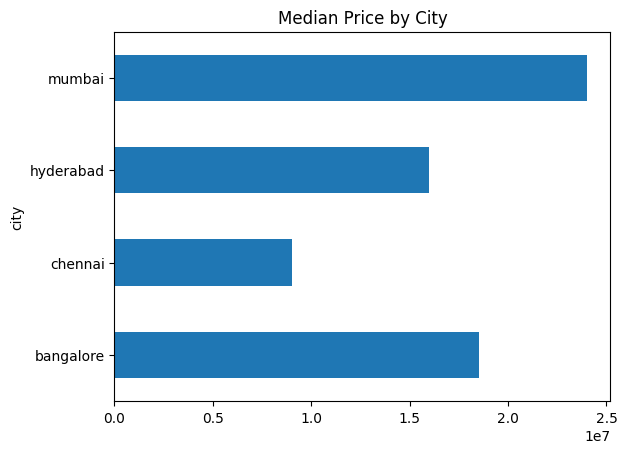

In [156]:
df.groupby('city')['price'].median().plot(kind='barh')
plt.title('Median Price by City')
plt.show()

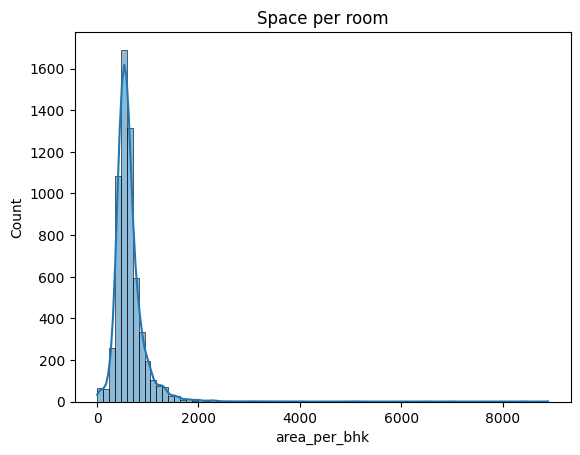

In [93]:
sns.histplot(df['area_per_bhk'], bins=76, kde=True)
plt.title('Space per room')
plt.show()

Typically rooms have area of under 2000 sqft per room, with few high value properties with extremely high square footage

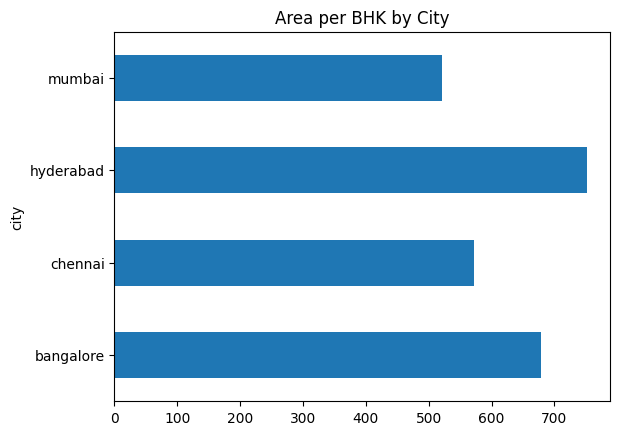

In [94]:
df.groupby('city')['area_per_bhk'].mean().plot(kind='barh')
plt.title('Area per BHK by City')
plt.show()

Hydrebad has more area per bhk

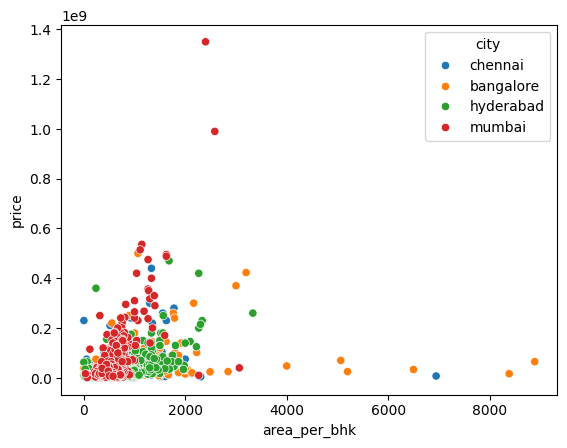

In [95]:
sns.scatterplot(data=df, x='area_per_bhk', y='price', hue='city')
plt.show()

Banglore has more spacious rooms for chapear pricing 

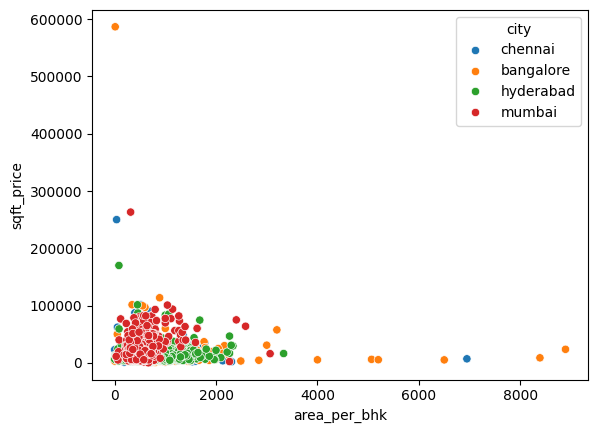

In [96]:
sns.scatterplot(data=df, x='area_per_bhk', y='sqft_price', hue='city')
plt.show()

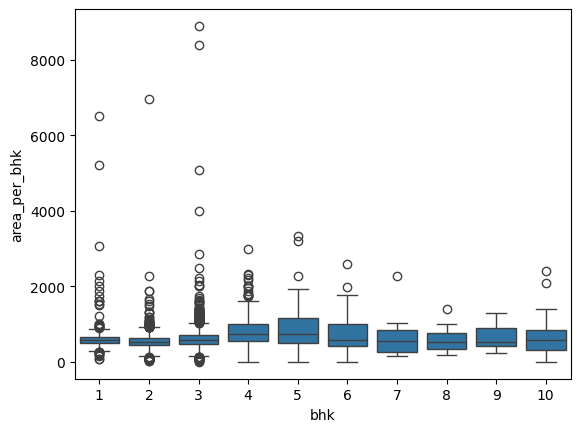

In [97]:
sns.boxplot(data=df, x='bhk', y='area_per_bhk')
plt.show()

high number of outiers in low bhk categories indicate luxurious properties

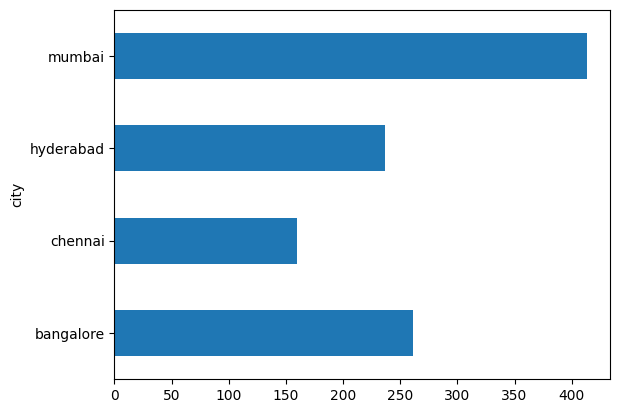

In [98]:
df.groupby('city')['price_in_lakhs'].mean().plot(kind='barh')
plt.show()

Mumbai has the most expensive listings, while cheanni has the cheapest

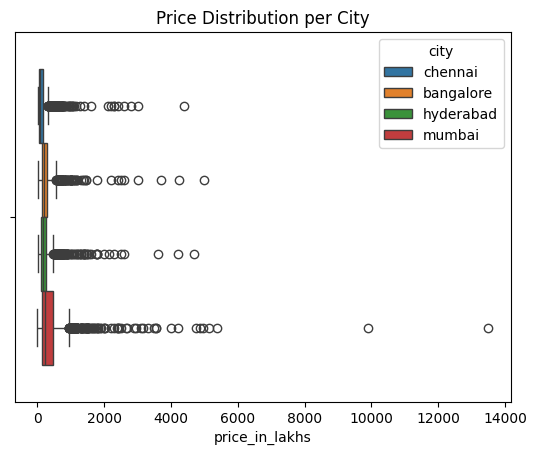

In [99]:
sns.boxplot(data= df, x='price_in_lakhs', hue='city')
plt.title('Price Distribution per City')
plt.show()

All cities have outliers, typical with real estate data. mumbai with extreme outliers

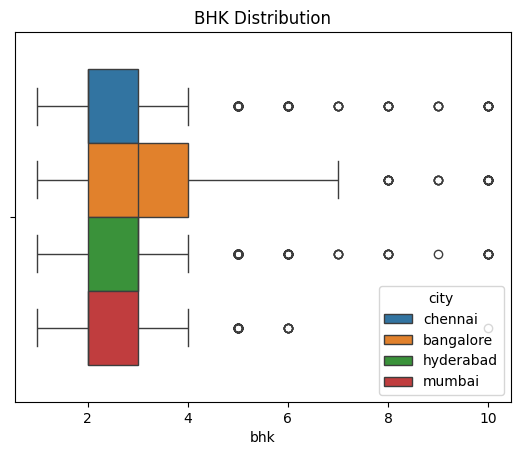

In [100]:
sns.boxplot(data=df, x='bhk', hue='city')
plt.title('BHK Distribution')
plt.show()

Banglore has slightly higher bhk

###  Price Distribution

We analyze the distribution of property prices to identify skewness and outliers.

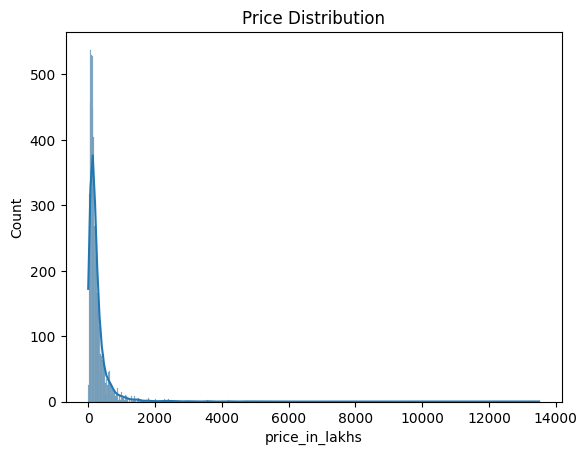

In [101]:
sns.histplot(df['price_in_lakhs'], bins='fd', kde=True)
plt.title('Price Distribution')
plt.show()

Right skewed, with extreme values. Typical with real estate data

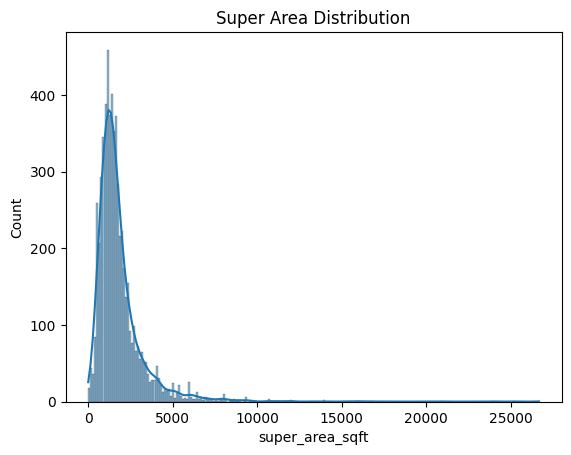

In [102]:
sns.histplot(df['super_area_sqft'], bins='fd', kde=True)
plt.title('Super Area Distribution')
plt.show()

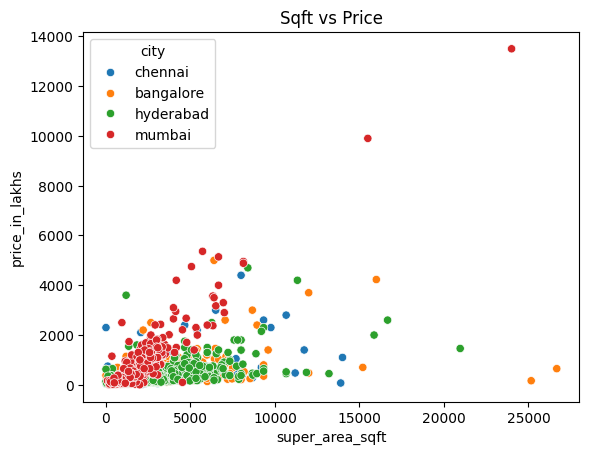

In [103]:
sns.scatterplot(data = df, x='super_area_sqft', y='price_in_lakhs', hue='city')
plt.title('Sqft vs Price')
plt.show()

The square footage in mumbai is lower for it's price compared to other states. we can also see the 2 extreme data points in mumbi with extremely high price and sqft

In [104]:
df.groupby(
    ['city', 'price_segment_by_city'],
    observed=True
)['price_in_lakhs'].median()

city       price_segment_by_city
bangalore  Affordable                152.0
           Budget                    100.0
           Luxury                    650.0
           Mid-range                 240.0
           Premium                   361.5
chennai    Affordable                 75.0
           Budget                     43.0
           Luxury                    467.5
           Mid-range                 120.0
           Premium                   222.5
hyderabad  Affordable                128.0
           Budget                     72.0
           Luxury                    655.0
           Mid-range                 198.0
           Premium                   325.0
mumbai     Affordable                185.0
           Budget                     95.0
           Luxury                   1175.0
           Mid-range                 325.0
           Premium                   610.0
Name: price_in_lakhs, dtype: float64

In [105]:
num_cols = ['price', 'sqft_price', 'bhk', 'bathroom', 'balcony', 'super_area_sqft', 'covered_parking', 'open_parking', 'floor_number',
            'total_floors', 'floor_ratio', 'total_parking'] 

Correlation Heatmap

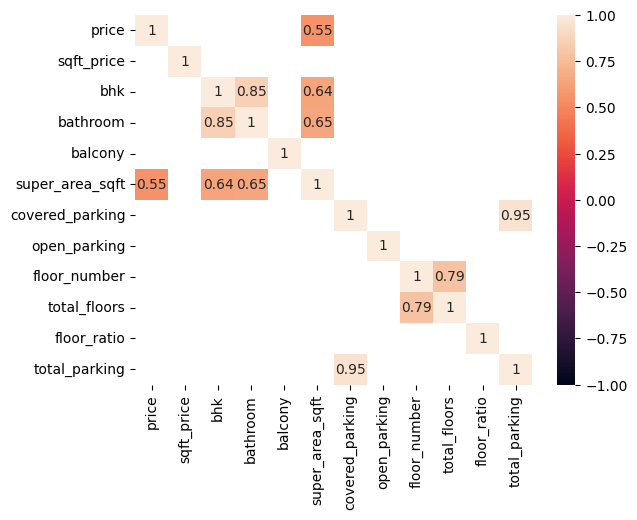

<Figure size 1500x1000 with 0 Axes>

In [106]:
corr = df[num_cols].corr()
mask = np.abs(corr) < 0.5
sns.heatmap(corr, annot=True, mask=mask, vmin= -1, vmax= 1 )
plt.figure(figsize=(15, 10))
plt.show()

In [107]:
df['coords'] = df['lat'] / df['lon']

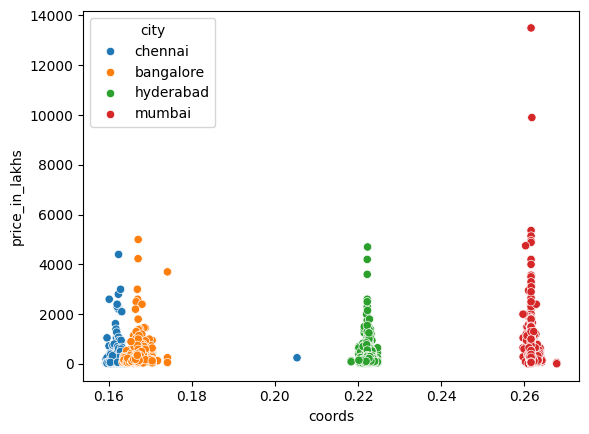

In [108]:
sns.scatterplot(data=df, x='coords', y='price_in_lakhs', hue='city')
plt.show()

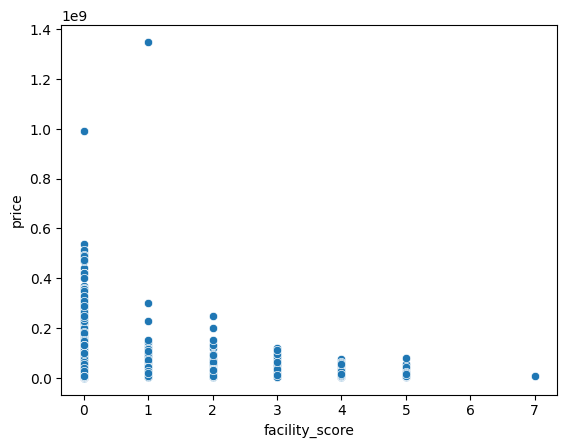

In [109]:
# Facility score vs price
sns.scatterplot(x='facility_score', y='price', data=df)
plt.show()

Could not get enough data for a meaniful analysis 

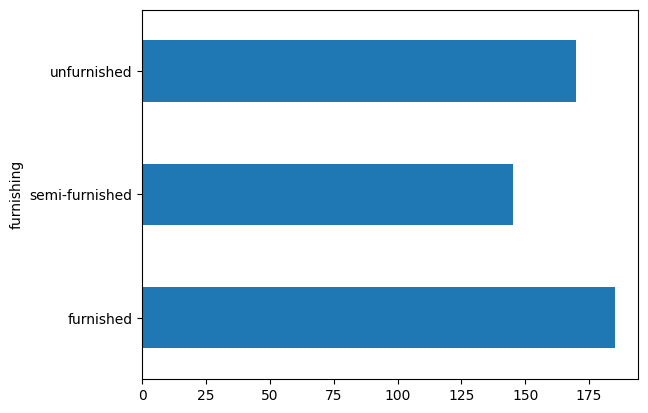

In [110]:
df.groupby('furnishing')['price_in_lakhs'].median().plot(kind='barh')
plt.show()

Furnished properties tend to have a higher price

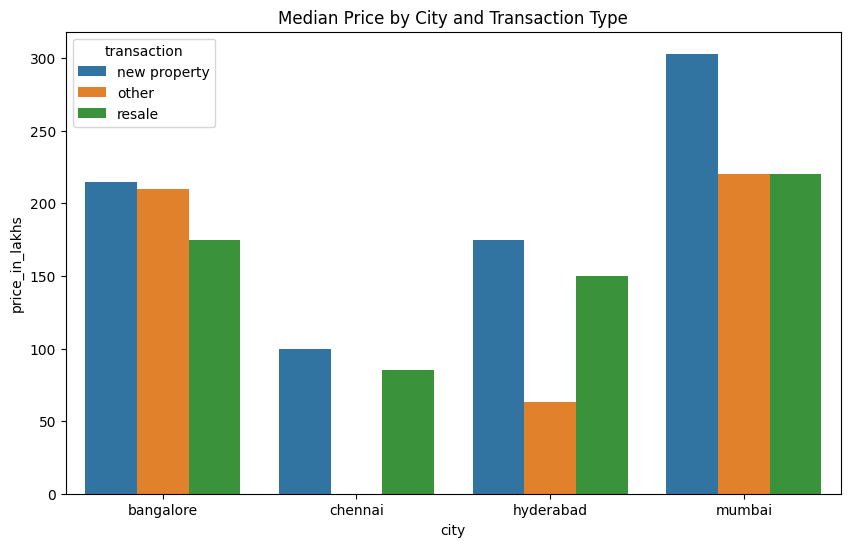

In [111]:
data = df.groupby(['city', 'transaction'])['price_in_lakhs'].median().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=data, x='city', y='price_in_lakhs', hue='transaction')
plt.title('Median Price by City and Transaction Type')
plt.show()

New properties sell for a higher price across all cities, especially in mumbai

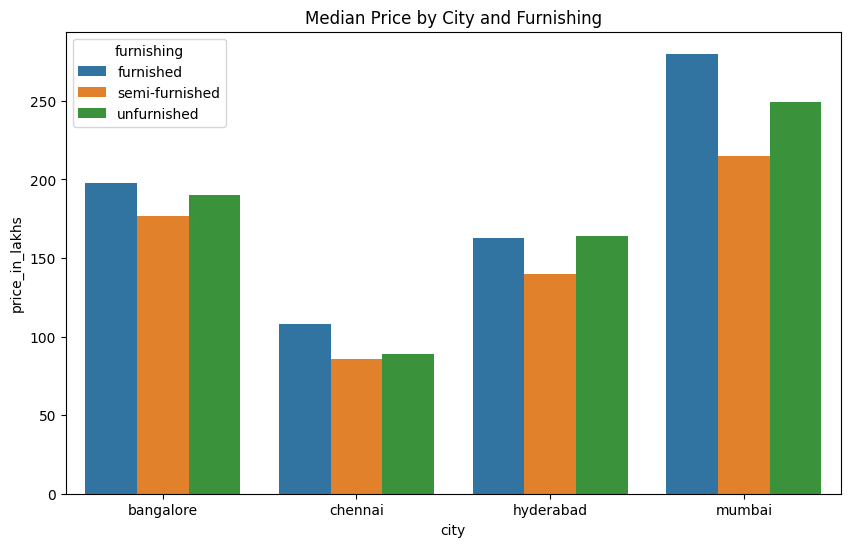

In [112]:
data1 = df.groupby(['city', 'furnishing'])['price_in_lakhs'].median().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=data1, x='city', y='price_in_lakhs', hue='furnishing')
plt.title('Median Price by City and Furnishing')
plt.show()

Furnished properties sell for a higher price across all cities, especially in mumbai

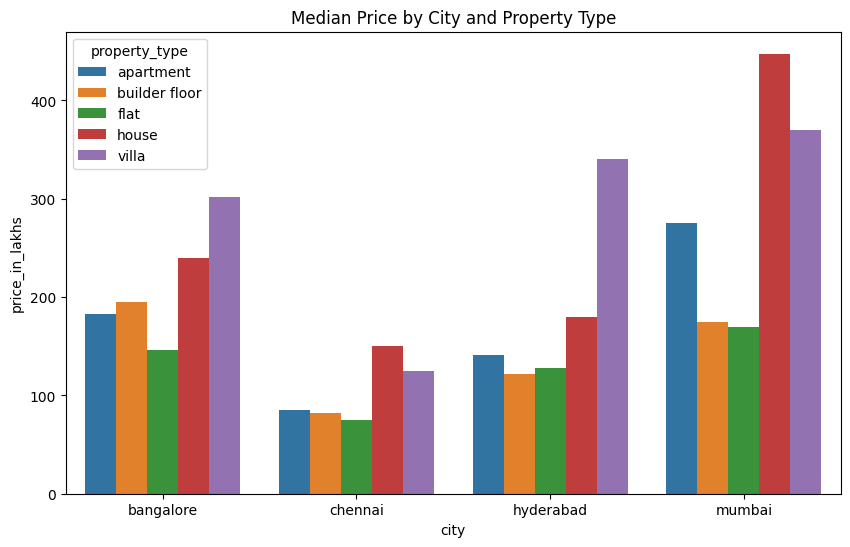

In [113]:
data2 = df.groupby(['city', 'property_type'])['price_in_lakhs'].median().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=data2, x='city', y='price_in_lakhs', hue='property_type')
plt.title('Median Price by City and Property Type')
plt.show()

Houses and villas are the more expensive acorss all cities

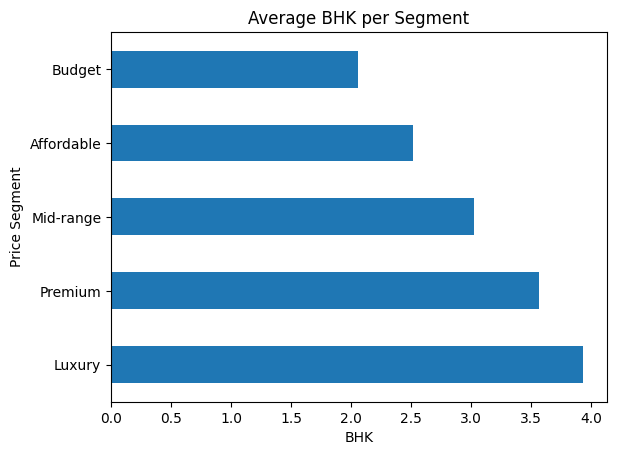

In [114]:
df.groupby('price_segment', observed=True)['bhk'].mean().sort_values(ascending=False).plot(kind='barh')
plt.ylabel('Price Segment')
plt.xlabel('BHK')
plt.title('Average BHK per Segment')
plt.show()

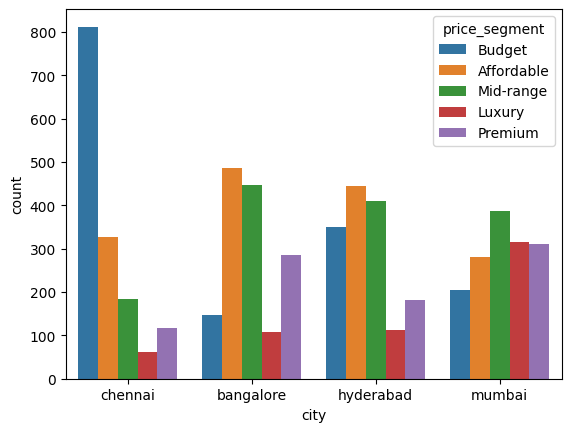

In [115]:
sns.countplot(data=df, x='city', hue='price_segment')
plt.show()

 Chennai provides the most affordable properties

# Location based clustering

In [116]:
# 1. Prepare data

coords = df[['lat', 'lon']].dropna()

# Convert to radians 
coords_rad = np.radians(coords)


##  Location Clustering (DBSCAN)

We use DBSCAN to cluster properties based on geographic coordinates.

### Why DBSCAN?
- Does not require predefined number of clusters
- Handles noise (outliers) effectively

In [117]:
# 2. DBSCAN model
# eps = distance in radians
# 0.01 ~ ~1 km (approx)
kms_per_radian = 6371.0088
eps_km = 1.5   
eps = eps_km / kms_per_radian

dbscan = DBSCAN(
    eps=eps,
    min_samples=10,
    metric='haversine'
)


In [118]:
# 3. Fit model
clusters = dbscan.fit_predict(coords_rad)


# 4. Assign back to dataframe
df.loc[coords.index, 'location_cluster'] = clusters

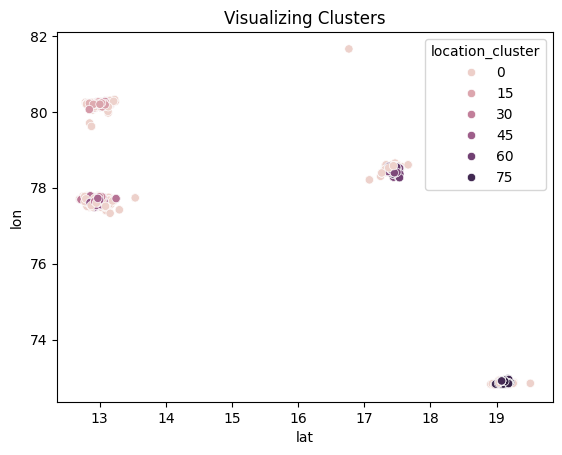

In [119]:
sns.scatterplot(data=df, x='lat', y='lon', hue='location_cluster')
plt.title('Visualizing Clusters')
plt.show()

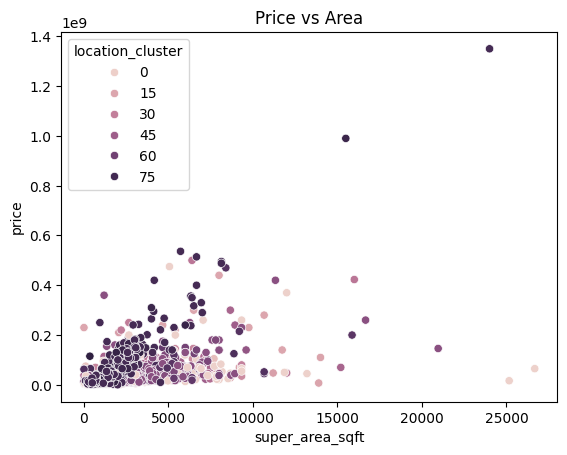

In [120]:
sns.scatterplot(data=df, x='super_area_sqft', y='price', hue='location_cluster')
plt.title('Price vs Area')
plt.show()

---

# House Price Prediction

---

##  Model Building

We experiment with multiple models:

- XGBoost → handles structured data well
- CatBoost → handles categorical variables efficiently

### Evaluation Metrics:
- R² Score → measures variance explained
- MAE → average prediction error
- RMSE → penalizes large errors

##  Hyperparameter Tuning (Optuna)

Optuna is used to efficiently search for optimal model parameters.

### Benefits:
- Faster than Grid Search
- Smarter search using Bayesian optimization

## CatBoost Algorithim

### Data Preperation

In [121]:
# making a copy
df1 = df.copy()

In [122]:
# Droping columns that could lead to data leakage
df1.drop(columns=['sqft_price', 'log_price', 'price_in_lakhs', 'price_segment', 
                  'price_segment_by_city', 'coords', 'location_cluster'], inplace=True)

In [123]:
# removing extreme outliers from the data
df1 = df1[df1['price'] < df1['price'].quantile(0.99)]

In [124]:
# Feature / Target Split

X = df1.drop(columns='price')
y = np.log1p(df1['price'])   # log transform



In [125]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [126]:
# Identify Categorical Features

cat_features = X.select_dtypes(include=['object']).columns.tolist()

In [127]:
# HYPERPARAMETER TUNING (OPTUNA)

import optuna

if os.path.exists(CBEST_PARAM_PATH) and not FORCE_TUNE:
    print("Loading saved CatBoost best params...")
    best_params = joblib.load(CBEST_PARAM_PATH)

else:
    print("Running CatBoost hyperparameter tuning...")

    def objective(trial):
        params = {
            "iterations": trial.suggest_int("iterations", 500, 1500),
            "depth": trial.suggest_int("depth", 4, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
            "random_strength": trial.suggest_float("random_strength", 0, 10),
            "border_count": trial.suggest_int("border_count", 32, 255),
            "rsm": trial.suggest_float("rsm", 0.5, 1.0),
            "loss_function": "RMSE",
            "eval_metric": "RMSE",
            "random_state": 42,
            "verbose": 0
        }

        model = CatBoostRegressor(**params)

        model.fit(
            X_train, y_train,
            cat_features=cat_features,
            eval_set=(X_test, y_test),
            early_stopping_rounds=50,
            verbose=False
        )

        preds = model.predict(X_test)
        return np.sqrt(mean_squared_error(y_test, preds))

    study = optuna.create_study(direction = "minimize")
    study.optimize(objective, n_trials=30)

    best_params = study.best_params

    joblib.dump(best_params, CBEST_PARAM_PATH)
    print("Best params saved!")

print("Best Params:", best_params)

Loading saved CatBoost best params...
Best Params: {'iterations': 1332, 'depth': 9, 'learning_rate': 0.02558887746345513, 'l2_leaf_reg': 4.03450995273046, 'bagging_temperature': 0.252523033536838, 'random_strength': 0.6542527672188292, 'border_count': 184, 'rsm': 0.6078275229627729}


### Model Training

In [128]:
#  Loads the model if already exists 
if os.path.exists(CMODEL_PATH) and not FORCE_RETRAIN:
    print("Loading saved CatBoost model...")
    model = joblib.load(CMODEL_PATH)

# Training the model if not already trained
else:
    print("Training CatBoost model...")

    # Model initialization
    model = CatBoostRegressor(
        **best_params,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_state=42,
        early_stopping_rounds=50,
        verbose=100
    )
    # Model training
    model.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        use_best_model=True
    )

    # Saving model 
    joblib.dump(model, CMODEL_PATH)
    print("Model saved!")

Loading saved CatBoost model...


### Predictions & Inverse Transformation

In [129]:
#  Predictions using the model
if os.path.exists(CPRED_PATH) and not FORCE_RETRAIN:
    print("Loading saved predictions...")

    with open(CPRED_PATH, "rb") as f:
        train_preds, test_preds = pickle.load(f)

else:
    print("Generating predictions...")

    train_preds_log = model.predict(X_train)
    test_preds_log = model.predict(X_test)
    
    # Inverse transformation
    train_preds = np.expm1(train_preds_log)
    test_preds = np.expm1(test_preds_log)

    with open(CPRED_PATH, "wb") as f:
        pickle.dump((train_preds, test_preds), f)

    print("Predictions saved!")

y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)

Loading saved predictions...


### Model Evaluation

In [130]:
# function to print evaluation metrics
def evaluate(y_true, y_pred):
    print("R2:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAPE(%):", (mean_absolute_percentage_error(y_true, y_pred)) * 100)
    

print("\n--- Train Performance ---")
evaluate(y_train_actual, train_preds)

print("\n--- Test Performance ---")
evaluate(y_test_actual, test_preds)

# Train vs Test R2
print("\nTrain R2:", r2_score(y_train_actual, train_preds))
print("Test R2:", r2_score(y_test_actual, test_preds))


--- Train Performance ---
R2: 0.8248410090945836
MAE: 4990696.656722231
RMSE: 9561387.801793572
MAPE(%): 22.744153117381284

--- Test Performance ---
R2: 0.6983647999962391
MAE: 7118338.014233375
RMSE: 13544112.314722814
MAPE(%): 29.075053333157193

Train R2: 0.8248410090945836
Test R2: 0.6983647999962391


###  Model Performance Analysis

- Model is able to explain 70% of the variance 
- Training score is higher than test score, indicating mild overfitting
- This may be due to:
  - High feature complexity
  - Noise in scraped data

### Possible Improvements:
- Feature selection
- Regularization tuning
- More data

### Saving the model

In [131]:
# save model
#joblib.dump(model, "CatBoost_house_price_model.pkl")

# Load later
# model = joblib.load("CatBoost_house_price_model.pkl")

### Displaying the key features based on it's importance

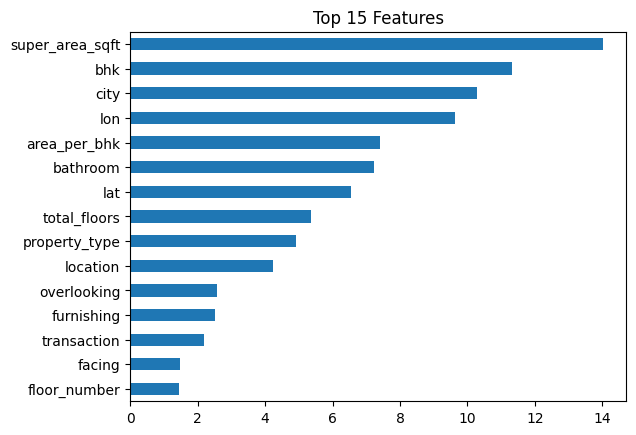

In [132]:

#  Feature Importance

feat_imp = pd.Series(
    model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

feat_imp.head(15).plot(kind='barh')
plt.title("Top 15 Features")
plt.gca().invert_yaxis()
plt.show()


In [133]:

# CREATE CATBOOST OUTPUT DATASET

# Train dataframe
train_df = pd.DataFrame({
    'actual_price': y_train_actual,
    'predicted_price': train_preds,
    'dataset_type': 'Train'
})

# Test dataframe
test_df = pd.DataFrame({
    'actual_price': y_test_actual,
    'predicted_price': test_preds,
    'dataset_type': 'Test'
})

# Combine
catboost_results = pd.concat([train_df, test_df]).reset_index(drop=True)


In [134]:

catboost_results['error'] = (
    catboost_results['actual_price'] -
    catboost_results['predicted_price']
)

catboost_results['abs_error'] = abs(catboost_results['error'])

catboost_results['pct_error'] = (
    catboost_results['abs_error'] /
    catboost_results['actual_price']
) * 100


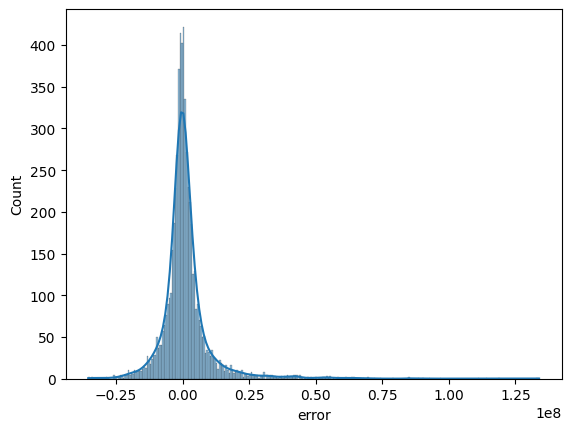

In [135]:

sns.histplot(data=catboost_results, x='error', bins='fd', kde=True)
plt.show()


In [136]:

# METRICS SUMMARY TABLE

metrics_df = pd.DataFrame({
    "dataset": ["Train", "Test"],
    "R2": [
        r2_score(y_train_actual, train_preds),
        r2_score(y_test_actual, test_preds)
    ],
    "MAE": [
        mean_absolute_error(y_train_actual, train_preds),
        mean_absolute_error(y_test_actual, test_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_actual, train_preds)),
        np.sqrt(mean_squared_error(y_test_actual, test_preds))
    ],
    "MAPE": [
        mean_absolute_percentage_error(y_train_actual, train_preds) * 100,
        mean_absolute_percentage_error(y_test_actual, test_preds) * 100
    ]
})


Saving results and metrics to csv

In [137]:
'''
catboost_results.to_csv("catboost_results.csv", index=False) 
metrics_df.to_csv("catboost_metrics.csv", index=False)
'''

'\ncatboost_results.to_csv("catboost_results.csv", index=False) \nmetrics_df.to_csv("catboost_metrics.csv", index=False)\n'

---

# Xgboost Algorithm

### Data Preparation

In [138]:
# Creating a working copy
df2 = df.copy()

# Remove extreme outliers (top 1% prices)
df2 = df2[df2['price'] < df2['price'].quantile(0.99)]

# Drop leakage-prone and redundant features
df2.drop(columns=['sqft_price', 'log_price', 'price_in_lakhs', 'price_segment', 
                  'price_segment_by_city', 'coords', 'facility_score' ], inplace=True)

### Setup & Target Transformation

In [139]:
#  Features & Target

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


target = 'price'

X = df2.drop(columns=[target])
y = df2[target]

# Log transform target (handles skewness)
y_log = np.log1p(y)


### Train-Test Split

In [140]:
#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)

### Feature Engineering Pipeline

In [141]:
#  Column Types 
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

#  Preprocessing (OneHotEncoder)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


### Hyperparameter Optimization using Optuna

In [142]:
# cheking if best parameters have already been identified
if os.path.exists(OPTUNA_PATH) and not FORCE_OPTUNA:
    print("Loading saved Optuna best params...")
    best_params = joblib.load(OPTUNA_PATH)

# hyperparameter tuning if not already tuned
else:
    print("Running Optuna...")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }

        model = xgb.XGBRegressor(**params)

        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model)
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
        return scores.mean()

    # Running optuna study
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30)

    best_params = study.best_params
    
    # Saving the best parameters for future use
    joblib.dump(best_params, OPTUNA_PATH)
    print("Optuna params saved!")

print("Best Params:", best_params)

Loading saved Optuna best params...
Best Params: {'n_estimators': 774, 'max_depth': 5, 'learning_rate': 0.02047537675533448, 'subsample': 0.601464106088171, 'colsample_bytree': 0.9996393247674188, 'gamma': 0.07078095450462432, 'reg_alpha': 1.6627959538684198, 'reg_lambda': 2.9707828602087063}


### Run Optuna Study

---

In [143]:
#  Run Optuna

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=30)

#print("Best Params:", study.best_params)

### Train Final Model

In [144]:
# looking for saved model, to reduce time and retraining 
if os.path.exists(XMODEL_PATH) and not FORCE_RETRAIN:
    print("Loading saved model...")
    final_pipeline = joblib.load(XMODEL_PATH)

# Trainging the model if not trained
else:
    print("Training final model...")

    best_model = xgb.XGBRegressor(
        **best_params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    final_pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', best_model)
    ])

    final_pipeline.fit(X_train, y_train)

    # Saving the model if not already saved
    joblib.dump(final_pipeline, XMODEL_PATH)
    print("Model saved!")

Loading saved model...


### Predictions & Inverse Transformation

In [145]:
# looking for saved prediction to save time
if os.path.exists(XPRED_PATH) and not FORCE_RETRAIN:
    print("Loading saved predictions...")

    with open(XPRED_PATH, "rb") as f:
        train_preds, test_preds = pickle.load(f)

else:
    print("Generating predictions...")

    train_preds_log = final_pipeline.predict(X_train)
    test_preds_log = final_pipeline.predict(X_test)

    train_preds = np.expm1(train_preds_log)
    test_preds = np.expm1(test_preds_log)

    with open(XPRED_PATH, "wb") as f:
        pickle.dump((train_preds, test_preds), f)

    print("Predictions saved!")

y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)

Loading saved predictions...


### Model Evaluation

In [146]:
#  Metrics
def evaluate(y_true, y_pred):
    print("R2:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAPE(%):", (mean_absolute_percentage_error(y_true, y_pred)) * 100)
    

print("\n--- Train Performance ---")
evaluate(y_train_actual, train_preds)

print("\n--- Test Performance ---")
evaluate(y_test_actual, test_preds)

# R2 comparison (overfitting check)
print("\nTrain R2:", r2_score(y_train_actual, train_preds))
print("Test R2:", r2_score(y_test_actual, test_preds))


--- Train Performance ---
R2: 0.802123489366849
MAE: 5295189.206717524
RMSE: 10162529.928268297
MAPE(%): 24.48189274656126

--- Test Performance ---
R2: 0.7016139766335794
MAE: 7235526.806779661
RMSE: 13470967.061826972
MAPE(%): 30.216982913052448

Train R2: 0.802123489366849
Test R2: 0.7016139766335794


### Xgboost still explains 70% of the variance

In [147]:
#  Save Model
#joblib.dump(final_pipeline, "Xgboost_house_price_model.pkl")

# to load later
# model = joblib.load("Xgboost_price_model.pkl")

#  Final Conclusion

###  Key Findings
- Location, property size, bhk are the strongest predictors of price
- Property prices vary significantly across cities and clusters
- Evidence of price saturation in certain high-demand regions

###  Business Recommendations
Based on the analysis:

- Segment-based modeling could improve prediction accuracy by capturing region-specific patterns  
- More consistent and structured data collection would help reduce noise and improve model reliability  
- Incorporating additional features such as amenities and neighborhood quality can enhance predictive performance  
- The interactive dashboard can be leveraged to identify investment opportunities and detect pricing inefficiencies  

###  Future Work
- Implement segment-wise or city-wise models  
- Integrate time-series data to capture market trends  
- Deploy the model as a real-time application for end users  

---

# Transforming Data For Advanced Visualization in Power BI

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5963 entries, 0 to 5999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   city                   5963 non-null   object 
 1   price                  5963 non-null   float64
 2   sqft_price             5963 non-null   float64
 3   posted_by              5963 non-null   object 
 4   bhk                    5963 non-null   Int64  
 5   property_type          5963 non-null   object 
 6   location               5963 non-null   object 
 7   transaction            5963 non-null   object 
 8   furnishing             5963 non-null   object 
 9   bathroom               5963 non-null   float64
 10  balcony                5963 non-null   float64
 11  facing                 5963 non-null   object 
 12  overlooking            5963 non-null   object 
 13  ownership              5963 non-null   object 
 14  super_area_sqft        5963 non-null   float64
 15  ready_to_

Droping columns

In [149]:
df.drop(columns=['log_price', 'price_in_lakhs','price_segment', 
                 'price_segment_by_city', 'coords', 'has_overlooking', 'has_parking'], inplace=True)

Creating Keys

In [150]:
df_star = df.copy()

df_star['property_id'] = df_star.index + 1

df_star['city_id'] = df_star['city'].astype('category').cat.codes

df_star['location_id'] = df_star['location'].astype('category').cat.codes

df_star['property_type_id'] = df_star['property_type'].astype('category').cat.codes

df_star['transaction_id'] = df_star['transaction'].astype('category').cat.codes

df_star['furnishing_id'] = df_star['furnishing'].astype('category').cat.codes

df_star['ownership_id'] = df_star['ownership'].astype('category').cat.codes

df_star['facing_id'] = df_star['facing'].astype('category').cat.codes

df_star['floor_category_id'] = df_star['floor_category'].astype('category').cat.codes

df_star['overlooking_id'] = df_star['overlooking'].astype('category').cat.codes

Creating Dimension Tables

In [151]:
dim_city = df_star[['city_id', 'city']].drop_duplicates()

dim_location = df_star[['location_id', 'location', 'city_id', 'lat', 'lon']].drop_duplicates()

dim_property = df_star[['property_type_id', 'property_type']].drop_duplicates()

dim_transaction = df_star[['transaction_id', 'transaction']].drop_duplicates()

dim_overlooking = df_star[['overlooking_id', 'overlooking']].drop_duplicates()

dim_furnishing = df_star[['furnishing_id', 'furnishing']].drop_duplicates()

dim_ownership = df_star[['ownership_id', 'ownership']].drop_duplicates()

dim_floor = df_star[['floor_category_id', 'floor_category']].drop_duplicates()

dim_facing = df_star[['facing_id', 'facing']].drop_duplicates()

Creating Fact Table

In [152]:
fact_property = df_star[[
    'price', 'sqft_price', 'super_area_sqft',
    'bhk', 'bathroom', 'balcony',
    'covered_parking', 'open_parking', 'total_parking',
    'facility_score', 'floor_number', 'total_floors',

    'property_id', 'city_id', 'location_id', 'property_type_id',
    'transaction_id', 'furnishing_id', 'overlooking_id',
    'ownership_id', 'facing_id', 'floor_category_id'
]]

In [153]:
print(fact_property.shape)
print(dim_city.shape)
print(dim_location.shape)
print(dim_property.shape)
print(dim_transaction.shape)
print(dim_overlooking.shape)
print(dim_facing.shape)
print(dim_floor.shape)
print(dim_ownership.shape)
print(dim_furnishing.shape)

(5963, 22)
(4, 2)
(2603, 5)
(5, 2)
(3, 2)
(9, 2)
(8, 2)
(3, 2)
(4, 2)
(3, 2)


Converting to CSV files

In [154]:
'''
fact_property.to_csv("fact_property.csv", index=False)

dim_city.to_csv("dim_city.csv", index=False)

dim_location.to_csv("dim_location.csv", index=False)

dim_transaction.to_csv("dim_transaction.csv", index=False)

dim_overlooking.to_csv("dim_overlooking.csv", index=False)

dim_property.to_csv("dim_property.csv", index=False)

dim_furnishing.to_csv("dim_furnishing.csv", index=False)

dim_facing.to_csv("dim_facing.csv", index=False)

dim_floor.to_csv("dim_floor.csv", index=False)

dim_ownership.to_csv("dim_ownership.csv", index=False)
'''

'\nfact_property.to_csv("fact_property.csv", index=False)\n\ndim_city.to_csv("dim_city.csv", index=False)\n\ndim_location.to_csv("dim_location.csv", index=False)\n\ndim_transaction.to_csv("dim_transaction.csv", index=False)\n\ndim_overlooking.to_csv("dim_overlooking.csv", index=False)\n\ndim_property.to_csv("dim_property.csv", index=False)\n\ndim_furnishing.to_csv("dim_furnishing.csv", index=False)\n\ndim_facing.to_csv("dim_facing.csv", index=False)\n\ndim_floor.to_csv("dim_floor.csv", index=False)\n\ndim_ownership.to_csv("dim_ownership.csv", index=False)\n'